In [3]:
import pandas as pd
df = pd.read_csv('최종전처리.csv', encoding='cp949')
df

,Unnamed: 0,시도,일시,fire,평균기온(°C),최고기온(°C),일강수량(mm),평균 상대습도(%),최대 풍속(m/s),평균 풍속(m/s),최저기온(°C),일 최심적설(cm),실효습도,년도,논_비율,밭_비율,도시_산림_인접지수
0,0,경북,2016-01-03,1,4.376923,16.3,0.0,72.415385,6.5,1.184615,-6.6,0.0,59.201499,2016,14.049405,19.069746,10.158780
1,1,경북,2016-01-04,0,5.192308,12.9,0.0,50.807692,8.3,2.715385,-6.2,0.0,55.198808,2016,14.049405,19.069746,10.158780
2,2,경북,2016-01-05,0,0.423077,7.0,0.0,33.076923,8.1,2.646154,-7.0,0.0,46.443746,2016,14.049405,19.069746,10.158780
3,3,경북,2016-01-06,1,0.084615,7.0,0.0,46.515385,9.6,2.976923,-9.8,0.0,43.977776,2016,14.049405,19.069746,10.158780
4,4,경북,2016-01-07,0,-0.030769,6.4,0.0,44.192308,8.1,3.092308,-9.2,0.0,41.731961,2016,14.049405,19.069746,10.158780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62013,63262,제주,2025-12-27,0,4.200000,9.4,0.0,59.325000,6.1,2.625000,-2.8,0.0,54.115659,2025,0.001604,7.444119,6.744372
62014,63263,제주,2025-12-28,0,8.950000,13.7,0.0,53.875000,12.7,2.800000,1.0,0.0,51.877249,2025,0.001604,7.444119,6.744372
62015,63264,제주,2025-12-29,0,12.325000,17.3,0.0,60.600000,11.5,4.400000,5.0,0.0,52.197272,2025,0.001604,7.444119,6.744372
62016,63265,제주,2025-12-30,0,8.325000,15.8,0.0,51.725000,10.3,3.700000,3.6,0.0,49.414664,2025,0.001604,7.444119,6.744372


In [4]:
df = df.drop(['Unnamed: 0'],axis=1)

In [5]:
df['일시'] = pd.to_datetime(df['일시'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62018 entries, 0 to 62017
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   시도          62018 non-null  object        
 1   일시          62018 non-null  datetime64[ns]
 2   fire        62018 non-null  int64         
 3   평균기온(°C)    62018 non-null  float64       
 4   최고기온(°C)    62018 non-null  float64       
 5   일강수량(mm)    62018 non-null  float64       
 6   평균 상대습도(%)  62018 non-null  float64       
 7   최대 풍속(m/s)  62018 non-null  float64       
 8   평균 풍속(m/s)  62018 non-null  float64       
 9   최저기온(°C)    62018 non-null  float64       
 10  일 최심적설(cm)  62018 non-null  float64       
 11  실효습도        62018 non-null  float64       
 12  년도          62018 non-null  int64         
 13  논_비율        62018 non-null  float64       
 14  밭_비율        62018 non-null  float64       
 15  도시_산림_인접지수  62018 non-null  float64       
dtypes: datetime64[ns](1), 

In [6]:
print(df.isnull().sum())

시도            0
일시            0
fire          0
평균기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
평균 상대습도(%)    0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최저기온(°C)      0
일 최심적설(cm)    0
실효습도          0
년도            0
논_비율          0
밭_비율          0
도시_산림_인접지수    0
dtype: int64


In [ ]:
# smote하지 않은 것
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
sc = StandardScaler()
df['시도'] = le.fit_transform(df['시도'])
df['일시'] = le.fit_transform(df['일시'])

X = df.drop('fire',axis=1).to_numpy()
y = df['fire'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=30,
    learning_rate=0.1,
    random_state=0
)

xgb_clf.fit(X_train_sc,y_train)
print(xgb_clf.score(X_train_sc,y_train))
print(xgb_clf.score(X_test_sc,y_test))

0.9999785006342313
0.9430506288294098


In [ ]:
# smote한 것
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
sc = StandardScaler()
df['시도'] = le.fit_transform(df['시도'])
df['일시'] = le.fit_transform(df['일시'])

X = df.drop('fire',axis=1).to_numpy()
y = df['fire'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X_train,y_train)

X_train_sc = sc.fit_transform(X_resample)
X_test_sc = sc.transform(X_test)

In [9]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=10,
    max_depth=10,
    learning_rate=0.1,
    random_state=0
)

xgb_clf.fit(X_train_sc,y_resample)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [10]:
print(xgb_clf.score(X_train_sc,y_resample))
print(xgb_clf.score(X_test_sc,y_test))

0.9219873942688441
0.8789422766849403


<Figure size 640x480 with 0 Axes>

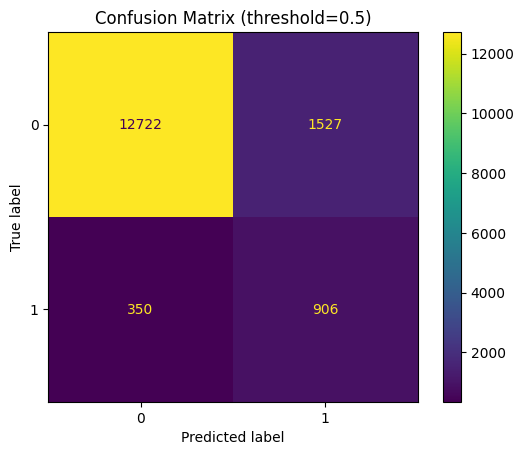

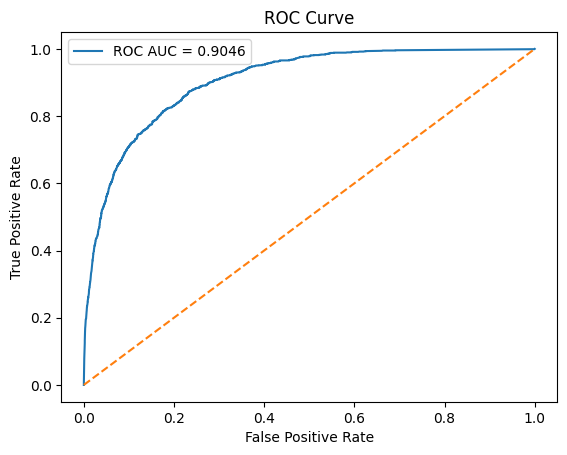

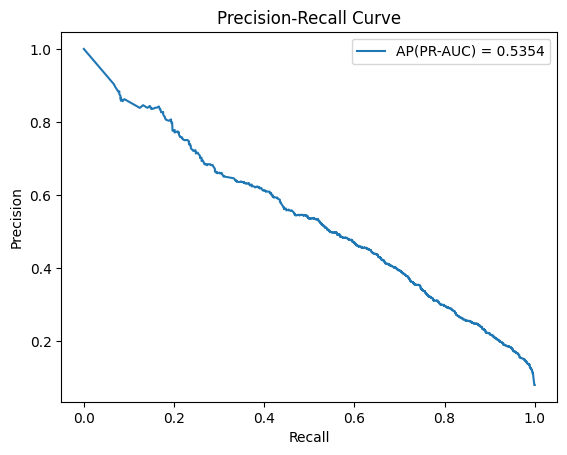

C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 45436 (\N{HANGUL SYLLABLE NON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\parks\AppData\Local\Temp\ipykernel_9704\3259587371.py:67: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(

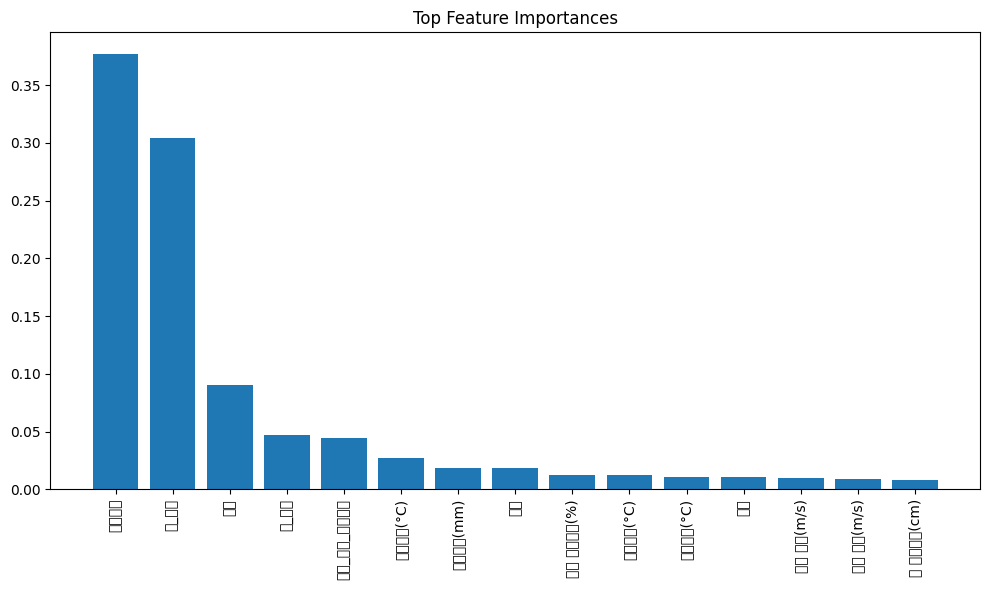

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# 1) 예측 확률/라벨
y_proba = xgb_clf.predict_proba(X_test_sc)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -----------------------
# (A) Confusion Matrix
# -----------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format='d')
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

# -----------------------
# (B) ROC Curve
# -----------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------
# (C) Precision-Recall Curve
# -----------------------
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label=f"AP(PR-AUC) = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# -----------------------
# (D) Feature Importance (XGBoost)
# -----------------------
# to_numpy()로 학습하면 컬럼명이 날아가서, df에서 컬럼명을 따로 가져와야 해요.
feature_names = df.drop(columns=['fire']).columns.tolist()

importances = xgb_clf.feature_importances_
idx = np.argsort(importances)[::-1]

top_k = min(20, len(feature_names))
plt.figure(figsize=(10, 6))
plt.bar(range(top_k), importances[idx][:top_k])
plt.xticks(range(top_k), [feature_names[i] for i in idx[:top_k]], rotation=90)
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()
